# IMU – Persistencia del Temblor en Reposo (MDS-UPDRS 3.18)

**Paciente con Parkinson**

La prueba 3.18 del MDS-UPDRS evalúa la persistencia del temblor en reposo:
qué porcentaje del tiempo de exploración presenta el paciente temblor en reposo.

**Dispositivos:** LEFT-HAND, RIGHT-HAND (+ BASE-SPINE como referencia).
Se reutilizan datos de prueba 3.16 (mano izquierda).

**Nota:** En un entorno clínico completo, 3.18 también evaluaría tobillo/pierna,
pero los datos disponibles solo incluyen sensores de mano.

**Escala MDS-UPDRS 3.18:**
| Score | Interpretación |
|-------|---------------|
| 0 | No hay temblor |
| 1 | Temblor presente ≤ 25 % del tiempo |
| 2 | Temblor presente 26–50 % del tiempo |
| 3 | Temblor presente 51–75 % del tiempo |
| 4 | Temblor presente > 75 % del tiempo |

Qué hace este notebook:
- Carga datos IMU y estima tasa de muestreo por dispositivo.
- Divide la señal en ventanas de 2 s con 50 % de solapamiento.
- Detecta temblor 3–8 Hz en cada ventana (Welch PSD + filtro pasa-banda).
- Calcula el porcentaje de ventanas con temblor y asigna score MDS-UPDRS 3.18.
- Genera línea de tiempo mostrando cuándo aparece el temblor.

In [1]:
# Imports y utilidades (con alternativas si SciPy no está)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [2]:
# Carga de JSON y aplanado
from pathlib import Path

# Archivo reutilizado para la prueba 3.18 Persistencia del temblor (Parkinson)
json_path = Path("../Datos/Parkinson/3.16-LEFT-HAND-Parkinson.json")
assert json_path.exists(), f"No se encontró el archivo: {json_path}"

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

patient = data.get('patient', {})
test_type = data.get('testType', None)
imu_data = data.get('imuData', [])
print(f"Registros IMU: {len(imu_data)} | TestType: {test_type}")
print("Paciente:", patient)

rows = []
for p in imu_data:
    acc = p.get('accelerometer', {}) or {}
    gyr = p.get('gyroscope', {}) or {}
    rows.append({
        'deviceId': p.get('deviceId', 'UNKNOWN'),
        'timestamp_ms': p.get('timestamp', np.nan),
        'ax': acc.get('x', np.nan), 'ay': acc.get('y', np.nan), 'az': acc.get('z', np.nan),
        'gx': gyr.get('x', np.nan), 'gy': gyr.get('y', np.nan), 'gz': gyr.get('z', np.nan),
    })

df = pd.DataFrame(rows).dropna(subset=['timestamp_ms','deviceId']).sort_values(['deviceId','timestamp_ms']).reset_index(drop=True)
assert not df.empty, "El DataFrame de señales está vacío"
df.head()

Registros IMU: 4859 | TestType: GAIT_ARMS
Paciente: {'birthDate': '16/10/2025', 'id': '16751329', 'name': 'Luis Felipe Jojoa Lasso', 'observations': 'Prueba Caviedez Brazo izquierdo tocarse la mano con la nariz'}


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,BASE-SPINE,428637,1.021362,-0.083008,0.047485,0.366211,-1.220703,-0.122070
1,BASE-SPINE,428663,1.022339,-0.081665,0.047852,0.427246,-1.281738,-0.183105
2,BASE-SPINE,428689,1.022095,-0.082153,0.045776,0.427246,-1.220703,-0.183105
3,BASE-SPINE,428716,1.023071,-0.081299,0.045898,0.305176,-0.976563,-0.183105
4,BASE-SPINE,428742,1.019531,-0.081421,0.046509,0.305176,-0.915527,-0.183105


In [3]:
# Preprocesamiento y ventana de 10 s
def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms)/1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0/med

df = df.copy()
df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = list(df['deviceId'].dropna().unique())
fs_map: Dict[str, float] = {d: estimate_fs_ms(df.loc[df['deviceId']==d, 'timestamp_ms'].to_numpy()) for d in devices}
fs_map

# Ventana común de 10 s centrada si es posible
per_dev_max = df.groupby('deviceId')['t'].max()
per_dev_min = df.groupby('deviceId')['t'].min()
global_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
global_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
dur = max(0.0, global_max - global_min)
if dur >= 10.0:
    start_t = global_min + (dur - 10.0)/2.0
    end_t = start_t + 10.0
else:
    start_t = global_min
    end_t = global_max
print(f"Ventana seleccionada: [{start_t:.2f}, {end_t:.2f}] s (dur={end_t-start_t:.2f}s)")

mask = (df['t'] >= start_t) & (df['t'] <= end_t)
df_win = df.loc[mask].copy()
assert not df_win.empty, "No hay datos en la ventana seleccionada"
df_win.head()

Ventana seleccionada: [16.91, 26.91] s (dur=10.00s)


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag
644,BASE-SPINE,445570,1.019897,-0.040039,-0.054688,0.366211,-0.122070,-0.244141,16.933,1.022147,0.456745
645,BASE-SPINE,445597,1.022339,-0.038452,-0.060669,0.549316,-0.122070,-0.366211,16.960,1.024859,0.671386
646,BASE-SPINE,445623,1.022827,-0.036377,-0.058350,0.427246,0.000000,-0.183105,16.986,1.025136,0.464830
647,BASE-SPINE,445649,1.024536,-0.038940,-0.057617,0.183105,0.000000,-0.122070,17.012,1.026893,0.220065
648,BASE-SPINE,445675,1.019409,-0.044922,-0.056519,0.366211,-0.183105,-0.427246,17.038,1.021962,0.591758


In [4]:
# Detección de temblor (Welch PSD + filtro pasa-banda 3–8 Hz)
from dataclasses import dataclass
from typing import Tuple

@dataclass
class TremorResult:
    device: str
    signal: str
    fs: float
    peak_freq_hz: float
    band_power: float
    total_power: float
    ratio: float
    rms_tremor: float
    band: Tuple[float, float]
    is_tremor: bool

def detect_tremor(sig: np.ndarray, fs: float, band: Tuple[float,float]=(3.0,8.0), broad: Tuple[float,float]=(0.5,15.0), rms_threshold: float=0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs*2)):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    x = np.asarray(sig, dtype=float) - np.mean(sig)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, False)
    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power/total_power) if total_power > 0 else 0.0
    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')
    y = simple_bandpass(x, fs, band[0], band[1])
    rms = float(np.sqrt(np.mean(y*y))) if y.size else 0.0
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, is_tremor)

In [5]:
# Análisis de persistencia de temblor en reposo (MDS-UPDRS 3.18)
# Se divide la señal en ventanas solapadas y se calcula el % de tiempo con temblor

from dataclasses import dataclass

@dataclass
class TremorPersistenceResult:
    device: str
    signal: str
    fs: float
    n_windows: int
    n_tremor_windows: int
    tremor_pct: float       # porcentaje de ventanas con temblor
    mean_ratio: float       # ratio medio de potencia en 3-8 Hz
    max_ratio: float        # ratio máximo
    mean_rms_tremor: float  # RMS medio de componente 3-8 Hz
    persistence_score: int  # MDS-UPDRS 3.18 (0-4)

def analyze_tremor_persistence(sig, fs, window_sec=2.0, overlap=0.5,
                                band=(3.0, 8.0), broad=(0.5, 15.0),
                                ratio_threshold=0.3, rms_threshold=0.02):
    # Evalúa en cuántas ventanas temporales hay temblor 3-8 Hz.
    if not np.isfinite(fs) or fs <= 0 or sig.size < int(fs * window_sec):
        return None

    x = np.asarray(sig, dtype=float)
    win_samples = int(fs * window_sec)
    step_samples = int(win_samples * (1 - overlap))
    if step_samples < 1:
        step_samples = 1

    ratios = []
    rms_vals = []
    tremor_flags = []

    start = 0
    while start + win_samples <= len(x):
        chunk = x[start:start + win_samples]
        chunk_centered = chunk - np.mean(chunk)

        f, Pxx = welch_psd(chunk_centered, fs=fs, nperseg=min(512, max(64, win_samples//2)))
        bmask = (f >= band[0]) & (f <= band[1])
        amask = (f >= broad[0]) & (f <= broad[1])

        if np.any(bmask) and np.any(amask):
            bp = trapz_power(f[bmask], Pxx[bmask])
            tp = trapz_power(f[amask], Pxx[amask])
            r = bp / tp if tp > 0 else 0.0
        else:
            r = 0.0

        y = simple_bandpass(chunk_centered, fs, band[0], band[1])
        rms = float(np.sqrt(np.mean(y**2))) if y.size else 0.0

        ratios.append(r)
        rms_vals.append(rms)
        tremor_flags.append(r >= ratio_threshold and rms >= rms_threshold)

        start += step_samples

    n_total = len(tremor_flags)
    n_tremor = sum(tremor_flags)
    pct = (n_tremor / n_total * 100.0) if n_total > 0 else 0.0

    # Score MDS-UPDRS 3.18
    if pct == 0:
        score = 0  # No hay temblor
    elif pct <= 25:
        score = 1  # <= 25 % del tiempo
    elif pct <= 50:
        score = 2  # 26–50 %
    elif pct <= 75:
        score = 3  # 51–75 %
    else:
        score = 4  # > 75 %

    return TremorPersistenceResult(
        device='', signal='', fs=fs,
        n_windows=n_total, n_tremor_windows=n_tremor,
        tremor_pct=pct,
        mean_ratio=float(np.mean(ratios)) if ratios else 0.0,
        max_ratio=float(np.max(ratios)) if ratios else 0.0,
        mean_rms_tremor=float(np.mean(rms_vals)) if rms_vals else 0.0,
        persistence_score=score
    )

# Ejecutar sobre ambas manos (ACC y GYRO)
hand_devices = [d for d in devices if 'HAND' in d]  # solo manos
persist_results = []
for dev in hand_devices:
    sub = df_win[df_win['deviceId'] == dev]
    if sub.empty:
        continue
    fs = fs_map.get(dev, float('nan'))
    # Acelerómetro
    res_acc = analyze_tremor_persistence(sub['acc_mag'].to_numpy(), fs, rms_threshold=0.02)
    if res_acc:
        res_acc.device = dev
        res_acc.signal = 'acc_mag'
        persist_results.append(res_acc)
    # Giroscopio
    res_gyro = analyze_tremor_persistence(sub['gyro_mag'].to_numpy(), fs, rms_threshold=0.5)
    if res_gyro:
        res_gyro.device = dev
        res_gyro.signal = 'gyro_mag'
        persist_results.append(res_gyro)

persist_df = pd.DataFrame([r.__dict__ for r in persist_results])
display(persist_df.round(4))

C:\Users\juanf\AppData\Local\Temp\ipykernel_29200\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


,device,signal,fs,n_windows,n_tremor_windows,tremor_pct,mean_ratio,max_ratio,mean_rms_tremor,persistence_score
0,LEFT-HAND,acc_mag,38.4615,7,5,71.4286,0.4245,0.7416,0.0369,3
1,LEFT-HAND,gyro_mag,38.4615,7,1,14.2857,0.0883,0.3931,11.3850,1
2,RIGHT-HAND,acc_mag,38.4615,9,0,0.0000,0.4430,0.6515,0.0022,0
3,RIGHT-HAND,gyro_mag,38.4615,9,4,44.4444,0.3659,0.6094,0.4518,2


C:\Users\juanf\AppData\Local\Temp\ipykernel_29200\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


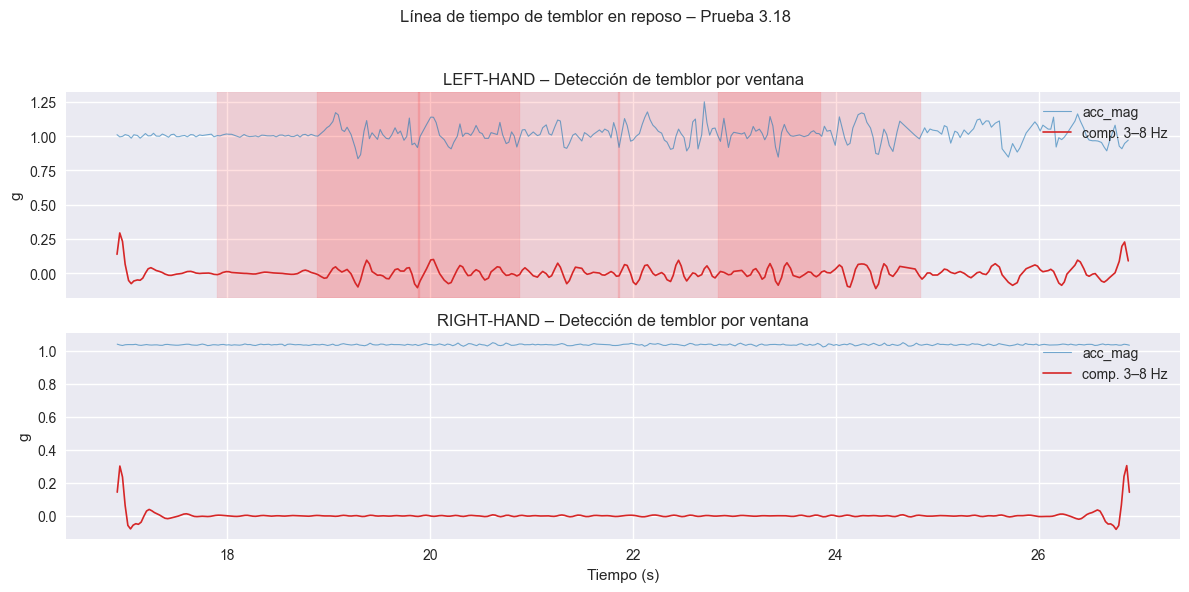

In [6]:
# Línea de tiempo de detección de temblor por ventana
if _USE_MPL and hand_devices:
    fig, axes = plt.subplots(nrows=len(hand_devices), ncols=1, figsize=(12, 3*len(hand_devices)), sharex=True)
    if len(hand_devices) == 1:
        axes = [axes]

    for ax, dev in zip(axes, hand_devices):
        sub = df_win[df_win['deviceId'] == dev]
        if sub.empty:
            continue
        fs = fs_map.get(dev, float('nan'))
        if not np.isfinite(fs) or fs <= 0:
            continue
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        acc_trem = simple_bandpass(acc, fs, 3, 8)

        ax.plot(t, acc, color='#1f77b4', lw=0.8, alpha=0.6, label='acc_mag')
        ax.plot(t, acc_trem, color='#d62728', lw=1.2, label='comp. 3–8 Hz')

        # Sombrear ventanas con temblor
        win_sec = 2.0
        overlap = 0.5
        win_samp = int(fs * win_sec)
        step_samp = int(win_samp * (1 - overlap))
        idx = 0
        t_start_sig = float(t[0])
        while idx + win_samp <= len(acc):
            chunk = acc[idx:idx+win_samp] - np.mean(acc[idx:idx+win_samp])
            fq, Pxx = welch_psd(chunk, fs=fs, nperseg=min(512, max(64, win_samp//2)))
            bm = (fq>=3)&(fq<=8)
            am = (fq>=0.5)&(fq<=15)
            bp2 = trapz_power(fq[bm], Pxx[bm])
            tp2 = trapz_power(fq[am], Pxx[am])
            r2 = bp2/tp2 if tp2>0 else 0
            y2 = simple_bandpass(chunk, fs, 3, 8)
            rms2 = float(np.sqrt(np.mean(y2**2)))
            if r2 >= 0.3 and rms2 >= 0.02:
                t0 = t_start_sig + idx / fs
                t1 = t0 + win_sec
                ax.axvspan(t0, t1, color='red', alpha=0.12)
            idx += step_samp

        ax.set_title(f'{dev} – Detección de temblor por ventana')
        ax.set_ylabel('g')
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Tiempo (s)')
    fig.suptitle('Línea de tiempo de temblor en reposo – Prueba 3.18')
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()
else:
    print('No hay backend matplotlib o no se encontraron dispositivos de mano.')

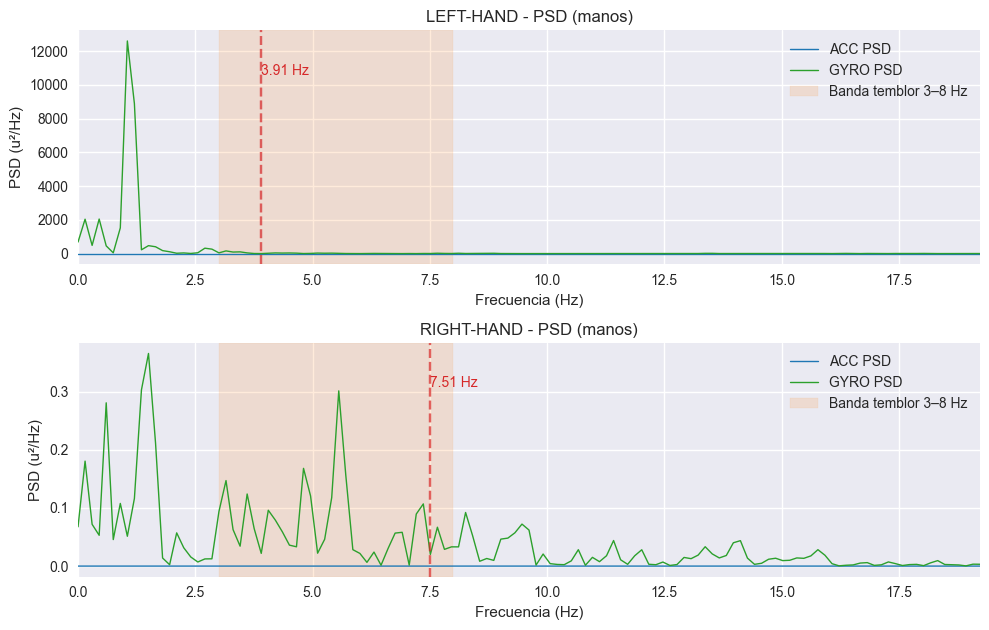

In [7]:
# PSD de manos con banda 3–8 Hz
if _USE_MPL and hand_devices:
    n = len(hand_devices)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(hand_devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda temblor 3–8 Hz')
        det = [r for r in persist_results if r.device==dev and r.persistence_score > 0]
        if det:
            # Marcar pico de PSD en banda de temblor
            bmask = (f_acc >= 3) & (f_acc <= 8)
            if np.any(bmask) and P_acc[bmask].size > 0:
                pk_idx = np.argmax(P_acc[bmask])
                pk_f = f_acc[bmask][pk_idx]
                ax.axvline(pk_f, color='#d62728', linestyle='--', alpha=0.7)
                ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                ax.text(pk_f, ymax*0.8, f"{pk_f:.2f} Hz", color='#d62728')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD (manos)')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
else:
    print('No hay backend matplotlib o no se encontraron dispositivos de mano.')

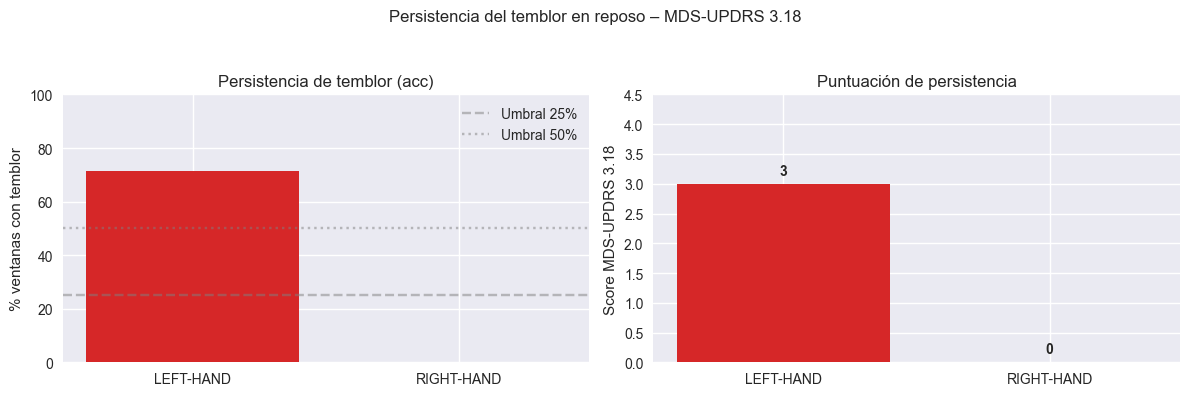

In [8]:
# Barras de persistencia de temblor
if _USE_MPL and not persist_df.empty:
    acc_data = persist_df[persist_df['signal']=='acc_mag']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Porcentaje de tiempo con temblor
    colors = ['#d62728' if p > 25 else '#2ca02c' for p in acc_data['tremor_pct']]
    axes[0].bar(acc_data['device'], acc_data['tremor_pct'], color=colors)
    axes[0].axhline(25, color='gray', linestyle='--', alpha=0.5, label='Umbral 25%')
    axes[0].axhline(50, color='gray', linestyle=':', alpha=0.5, label='Umbral 50%')
    axes[0].set_ylabel('% ventanas con temblor')
    axes[0].set_title('Persistencia de temblor (acc)')
    axes[0].legend()
    axes[0].set_ylim(0, 100)

    # Score MDS-UPDRS
    axes[1].bar(acc_data['device'], acc_data['persistence_score'],
                color=['#d62728' if s > 0 else '#2ca02c' for s in acc_data['persistence_score']])
    axes[1].set_ylabel('Score MDS-UPDRS 3.18')
    axes[1].set_title('Puntuación de persistencia')
    axes[1].set_ylim(0, 4.5)
    for idx_row, row in acc_data.iterrows():
        axes[1].text(row['device'], row['persistence_score'] + 0.15,
                     f"{row['persistence_score']}", ha='center', fontweight='bold')

    fig.suptitle('Persistencia del temblor en reposo – MDS-UPDRS 3.18')
    fig.tight_layout(rect=[0,0,1,0.93])
    plt.show()
else:
    print('No hay datos o matplotlib no disponible.')

## Interpretación para esta tarea

- Se analizan las **manos** (LEFT-HAND, RIGHT-HAND) buscando temblor en reposo en la banda 3–8 Hz.
- Cada ventana de 2 s se evalúa independientemente: si la potencia relativa en 3–8 Hz ≥ 30 % y el RMS filtrado ≥ umbral, se marca como «con temblor».
- El porcentaje de ventanas con temblor determina el score.
- Un paciente con Parkinson **puede mostrar** temblor persistente (score ≥ 1).
- **Limitación:** no se dispone de sensores de tobillo/pierna en estos datos.

In [9]:
# Resumen y puntuación MDS-UPDRS 3.18

print("="*60)
print("  RESUMEN – MDS-UPDRS 3.18: Persistencia del Temblor en Reposo")
print("  Paciente con Parkinson")
print("="*60)

if 'persist_df' in globals() and not persist_df.empty:
    display(persist_df[['device','signal','n_windows','n_tremor_windows','tremor_pct','mean_ratio','persistence_score']].round(4))

    # Score global = máximo entre dispositivos de mano (peor caso)
    global_score = int(persist_df['persistence_score'].max())
    score_labels = {
        0: "No hay temblor en reposo (0 % del tiempo)",
        1: "Temblor presente ≤ 25 % del tiempo",
        2: "Temblor presente 26–50 % del tiempo",
        3: "Temblor presente 51–75 % del tiempo",
        4: "Temblor presente > 75 % del tiempo"
    }
    print(f"\nPuntuación global estimada MDS-UPDRS 3.18: {global_score} / 4")
    print(f"Interpretación: {score_labels.get(global_score, 'N/A')}")

    # En un paciente con Parkinson se espera temblor en reposo persistente (score >= 1)
    print("\nNota: Los datos IMU utilizados son de la prueba 3.16 (mano izquierda) reutilizados para ilustrar el análisis.")
    print("En un entorno clínico real, la prueba 3.18 evalúa el temblor en reposo observando al paciente sentado con las manos en el regazo.")
    print("Los dispositivos ideales incluirían también tobillo/pierna; aquí solo se dispone de sensores de mano.")
else:
    print('No hay resultados para mostrar.')

  RESUMEN – MDS-UPDRS 3.18: Persistencia del Temblor en Reposo
  Paciente con Parkinson


,device,signal,n_windows,n_tremor_windows,tremor_pct,mean_ratio,persistence_score
0,LEFT-HAND,acc_mag,7,5,71.4286,0.4245,3
1,LEFT-HAND,gyro_mag,7,1,14.2857,0.0883,1
2,RIGHT-HAND,acc_mag,9,0,0.0000,0.4430,0
3,RIGHT-HAND,gyro_mag,9,4,44.4444,0.3659,2



Puntuación global estimada MDS-UPDRS 3.18: 3 / 4
Interpretación: Temblor presente 51–75 % del tiempo

Nota: Los datos IMU utilizados son de la prueba 3.16 (mano izquierda) reutilizados para ilustrar el análisis.
En un entorno clínico real, la prueba 3.18 evalúa el temblor en reposo observando al paciente sentado con las manos en el regazo.
Los dispositivos ideales incluirían también tobillo/pierna; aquí solo se dispone de sensores de mano.
